In [2]:
!pip install pydicom opencv-python tqdm


In [3]:
import os
import cv2
import pydicom 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


In [4]:
BASE_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"
DICOM_PATH = os.path.join(BASE_PATH, "train")
CSV_PATH = os.path.join(BASE_PATH, "train.csv")

OUTPUT_IMAGE_PATH = "/kaggle/working/images"
OUTPUT_LABEL_PATH = "/kaggle/working/labels"

os.makedirs(OUTPUT_IMAGE_PATH, exist_ok=True)
os.makedirs(OUTPUT_LABEL_PATH, exist_ok=True)


In [5]:
os.listdir(BASE_PATH)  #To check the datasets in BASE_PATH


['sample_submission.csv', 'train.csv', 'test', 'train']

In [6]:
def dicom_to_png(dicom_path, output_path, limit=2000):
    files = os.listdir(dicom_path)
    count = 0
    
    for file in tqdm(files):
        if file.endswith(".dicom") or file.endswith(".dcm"):    #Convert first 1000 images to PNG format out of 15000 images
            
            if count >= limit:   # Hard stop condition
                break
            
            full_path = os.path.join(dicom_path, file)
            
            try:
                dcm = pydicom.dcmread(full_path)
                img = dcm.pixel_array
                
                # Normalize safely
                img = img - np.min(img)
                if np.max(img) != 0:
                    img = img / np.max(img)
                
                img = (img * 255).astype(np.uint8)
                
                output_file = file.replace(".dicom", ".png").replace(".dcm", ".png")
                cv2.imwrite(os.path.join(output_path, output_file), img)
                
                count += 1
            
            except Exception as e:
                print(f"Error with {file}: {e}")

    print(f"Total converted: {count}")

dicom_to_png(DICOM_PATH, OUTPUT_IMAGE_PATH, limit=2000)

 13%|█▎        | 2000/15000 [32:01<3:28:11,  1.04it/s]

Total converted: 2000


Converted sample image


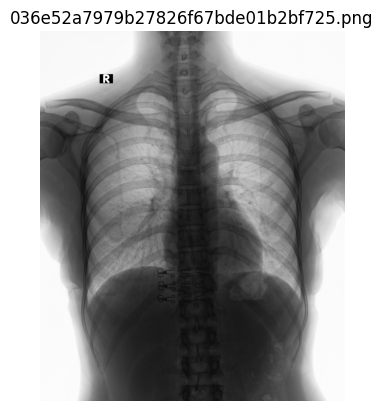

In [7]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[1]
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img), 0)

plt.imshow(img, cmap='gray')
plt.rcParams["figure.figsize"] = (7, 7)
plt.title(sample_img)
plt.axis("off")
print("Converted sample image")
plt.show()


In [8]:
df = pd.read_csv(CSV_PATH)
df.head()


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [9]:
classes = df['class_name'].unique()
class_dict = {name: i for i, name in enumerate(classes)}

print(class_dict)


{'No finding': 0, 'Cardiomegaly': 1, 'Aortic enlargement': 2, 'Pleural thickening': 3, 'ILD': 4, 'Nodule/Mass': 5, 'Pulmonary fibrosis': 6, 'Lung Opacity': 7, 'Atelectasis': 8, 'Other lesion': 9, 'Infiltration': 10, 'Pleural effusion': 11, 'Calcification': 12, 'Consolidation': 13, 'Pneumothorax': 14}


In [10]:
grouped = df.groupby("image_id")

for image_id, group in tqdm(grouped):
    
    img_file = os.path.join(OUTPUT_IMAGE_PATH, image_id + ".png")
    
    if not os.path.exists(img_file):
        continue
    
    img = cv2.imread(img_file)
    h, w, _ = img.shape
    
    label_file = os.path.join(OUTPUT_LABEL_PATH, image_id + ".txt")
    
    with open(label_file, "w") as f:
        for _, row in group.iterrows():
            
            # Skip No Finding (NaN boxes)
            if pd.isna(row.x_min):
                continue
            
            x_center = ((row.x_min + row.x_max) / 2) / w
            y_center = ((row.y_min + row.y_max) / 2) / h
            width = (row.x_max - row.x_min) / w
            height = (row.y_max - row.y_min) / h
            
            class_id = class_dict[row.class_name]
            
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")


100%|██████████| 15000/15000 [02:13<00:00, 112.38it/s]


In [11]:
import os

for file in os.listdir(OUTPUT_LABEL_PATH)[:20]:
    path = os.path.join(OUTPUT_LABEL_PATH, file)
    
    if os.path.getsize(path) > 0:
        print("Found non-empty label file:", file)
        with open(path) as f:
            print(f.read())
        break


Found non-empty label file: 9074b5859c254e4cc0d1ae9781cfcdf1.txt
5 0.2571614583333333 0.35260416666666666 0.04123263888888889 0.03229166666666667
5 0.25390625 0.3541666666666667 0.033854166666666664 0.027777777777777776
5 0.2575954861111111 0.3545138888888889 0.03342013888888889 0.034027777777777775
12 0.2575954861111111 0.3545138888888889 0.03342013888888889 0.034027777777777775



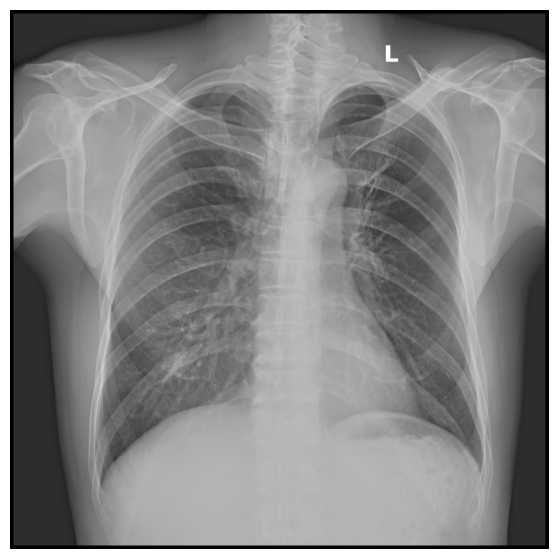

In [12]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[7]  
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img))

h, w, _ = img.shape            #To check if any abnormalities found in the image the bounding box correctly displays it

label_path = os.path.join(OUTPUT_LABEL_PATH, sample_img.replace(".png", ".txt"))

if os.path.exists(label_path):
    with open(label_path) as f:
        lines = f.readlines()
        
    for line in lines:
        class_id, xc, yc, bw, bh = map(float, line.split())
        
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.rcParams["figure.figsize"] = (7, 7)
plt.show()


In [13]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
INPUT_FOLDER = OUTPUT_IMAGE_PATH          # Your converted PNG images
PROCESSED_FOLDER = "/kaggle/working/processed_images"

os.makedirs(PROCESSED_FOLDER, exist_ok=True)

TARGET_SIZE = 640

# -------- Crop Function --------
def crop_black_borders(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
        
    _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]
        
    return img


# -------- Processing Loop --------
for image_name in tqdm(os.listdir(INPUT_FOLDER)):
    
    image_path = os.path.join(INPUT_FOLDER, image_name)
    img = cv2.imread(image_path)
    
    if img is None:
        continue
    
    # 1. Convert to Grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2️. Crop Borders
    img = crop_black_borders(img)
    
    # 3️. Resize
    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    
    # 4️. CLAHE (Light Contrast Enhancement)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    # 5️. Light Denoising (Gaussian Blur)
    img = cv2.GaussianBlur(img, (3,3), 0)
    
    # Save processed image
    save_path = os.path.join(PROCESSED_FOLDER, image_name)
    cv2.imwrite(save_path, img)

print("Preprocessing Completed Successfully!")


100%|██████████| 2000/2000 [05:49<00:00,  5.72it/s]

Preprocessing Completed Successfully!


Image shape: (640, 640)


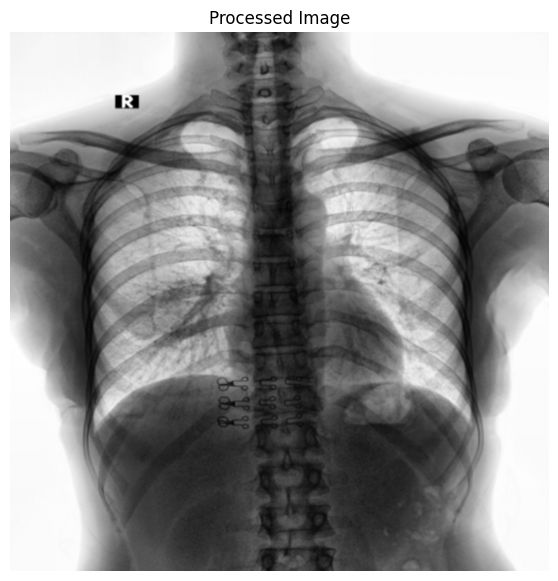

In [14]:
import matplotlib.pyplot as plt

# Pick one processed image
sample_img = os.listdir(PROCESSED_FOLDER)[1]
img_path = os.path.join(PROCESSED_FOLDER, sample_img)

img = cv2.imread(img_path, 0)

print("Image shape:", img.shape)

plt.figure(figsize=(7,7))
plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.axis("off")
plt.show()


In [15]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Base directory
BASE_DIR = "/kaggle/working/yolo_dataset"
os.makedirs(BASE_DIR, exist_ok=True)

# Create folder structure
for folder in [
    "images/train", "images/val", "images/test",
    "labels/train", "labels/val", "labels/test"
]:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

In [16]:
IMAGE_FOLDER = PROCESSED_FOLDER
LABEL_FOLDER = OUTPUT_LABEL_PATH

# Get all images
images = os.listdir(IMAGE_FOLDER)

# Split dataset
train_imgs, temp_imgs = train_test_split(
    images, test_size=0.3, random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs, test_size=0.33, random_state=42
)

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))



Train: 1400
Val: 402
Test: 198


In [17]:
def move_files(image_list, split_type):
    for img_name in image_list:
        
        # Move image
        src_img = os.path.join(IMAGE_FOLDER, img_name)
        dst_img = os.path.join(BASE_DIR, "images", split_type, img_name)
        shutil.copy(src_img, dst_img)

        # Move corresponding label
        label_name = img_name.replace(".png", ".txt")
        src_label = os.path.join(LABEL_FOLDER, label_name)

        if os.path.exists(src_label):
            dst_label = os.path.join(BASE_DIR, "labels", split_type, label_name)
            shutil.copy(src_label, dst_label)


# Execute splits
move_files(train_imgs, "train")
move_files(val_imgs, "val")
move_files(test_imgs, "test")

print("Dataset split completed!")

Dataset split completed!


In [18]:
import shutil

source_folder = "/kaggle/working/processed_images"
zip_path = "/kaggle/working/processed_images.zip"

shutil.make_archive(
    "/kaggle/working/processed_images",
    'zip',
    source_folder
)

print("Preprocessed images zipped successfully.")

Preprocessed images zipped successfully.


In [20]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score

In [21]:
# Load CSV
df = pd.read_csv("/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv")

# Group labels per image
grouped = df.groupby("image_id")["class_name"].apply(list).reset_index()

# Multi-label encoding
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(grouped["class_name"])
grouped["encoded_labels"] = list(labels)

# Create image paths
image_dir = "/kaggle/working/processed_images"

grouped["image_path"] = grouped["image_id"].apply(
    lambda x: os.path.join(image_dir, x + ".png")
)

# Remove missing images
grouped = grouped[grouped["image_path"].apply(os.path.exists)]

print("Total images:", len(grouped))

Total images: 2000


In [22]:
train_df, val_df = train_test_split(
    grouped,
    test_size=0.2,
    random_state=42
)

train_paths = train_df["image_path"].tolist()
train_labels = train_df["encoded_labels"].tolist()

val_paths = val_df["image_path"].tolist()
val_labels = val_df["encoded_labels"].tolist()

print("Train:", len(train_paths))
print("Validation:", len(val_paths))

Train: 1600
Validation: 400


In [24]:
class ChestXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = torch.FloatTensor(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

In [25]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # 🔥 Classification size
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [27]:
train_dataset = ChestXrayDataset(train_paths, train_labels, transform)
val_dataset = ChestXrayDataset(val_paths, val_labels, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights="DEFAULT")

num_features = model.fc.in_features
num_classes = len(train_labels[0])

model.fc = nn.Linear(num_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s] 


In [30]:
labels_array = np.array(train_labels)

pos_weight = torch.tensor(
    (len(labels_array) - labels_array.sum(axis=0)) /
    (labels_array.sum(axis=0) + 1e-6)
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [31]:
train_losses = []
val_losses = []
f1_scores = []

In [32]:
num_epochs = 5
best_f1 = 0

train_losses = []
val_losses = []
f1_scores = []

for epoch in range(num_epochs):

    # ---- TRAIN ----
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)


    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.sigmoid(outputs)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    binary_preds = (all_preds > 0.5).astype(int)

    f1 = f1_score(all_targets, binary_preds, average="macro", zero_division=0)
    f1_scores.append(f1)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"F1 Score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_classification_model.pth")
        print("✅ Best model saved!")


Epoch 1/5
Train Loss: 1.2029
Val Loss: 41.3394
F1 Score: 0.1886
✅ Best model saved!

Epoch 2/5
Train Loss: 1.1680
Val Loss: 1.1677
F1 Score: 0.1766

Epoch 3/5
Train Loss: 1.0531
Val Loss: 2.1096
F1 Score: 0.2142
✅ Best model saved!

Epoch 4/5
Train Loss: 0.9815
Val Loss: 1.1227
F1 Score: 0.2085

Epoch 5/5
Train Loss: 1.0000
Val Loss: 1.0410
F1 Score: 0.1985


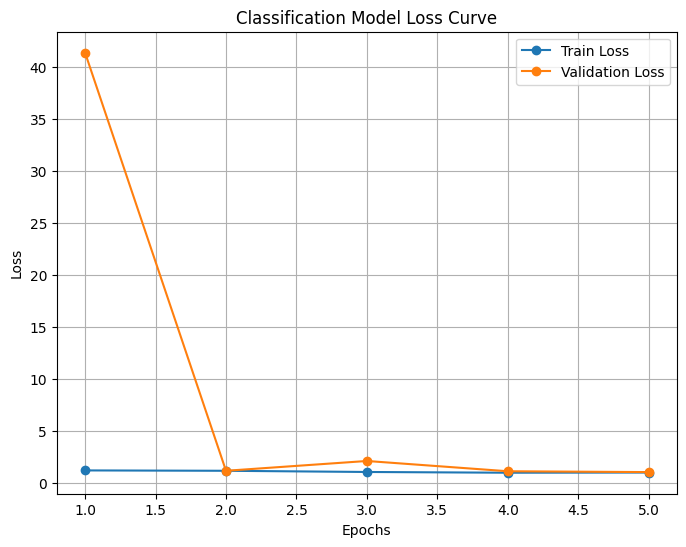

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Classification Model Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

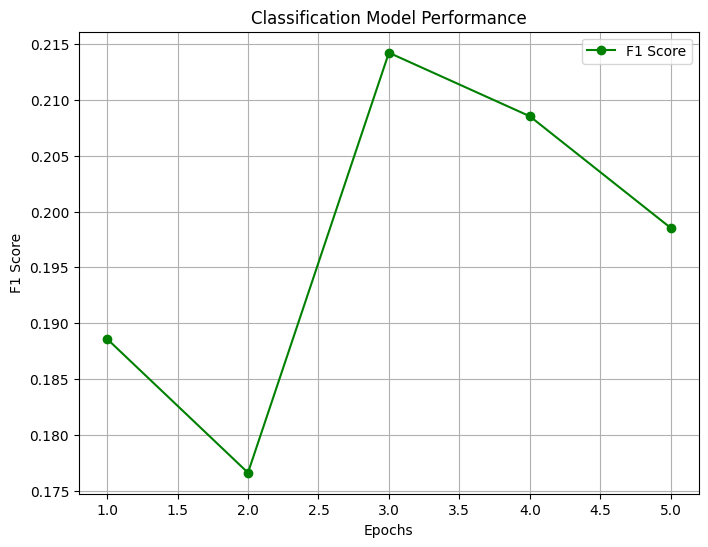

In [34]:
plt.figure(figsize=(8,6))

plt.plot(epochs, f1_scores, marker='o', color="green", label="F1 Score")

plt.xlabel("Epochs")
plt.ylabel("F1 Score")
plt.title("Classification Model Performance")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
!pip install ultralytics -q

In [38]:
import yaml

# your class_dict from earlier
# example: {'Aortic enlargement':0, 'Atelectasis':1, ...}

data = {
    'train': '/kaggle/working/yolo_dataset/images/train',
    'val': '/kaggle/working/yolo_dataset/images/val',
    'test': '/kaggle/working/yolo_dataset/images/test',
    'nc': len(class_dict),
    'names': list(class_dict.keys())
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data, f)

print("data.yaml created")

data.yaml created


In [41]:
from ultralytics import YOLO

# Load medium model (recommended)
model = YOLO('yolov8m.pt')

# Train for 20 epochs
model.train(
    data='/kaggle/working/data.yaml',
    epochs=20,        # 👈 set to 20
    imgsz=640,
    batch=8,
    device=0,
    lr0=0.001,
    degrees=10,       # small rotation (medical safe)
    fliplr=0.5,       # horizontal flip allowed
    hsv_h=0,
    hsv_s=0,
    hsv_v=0,
    perspective=0,
    shear=0
)

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0, hsv_s=0, hsv_v=0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0, plots=True, 

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 759.4±565.4 MB/s, size: 190.0 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 402 images, 296 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 402/402 14.5Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000526, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Plotting labels to /kaggle/working/runs/detect/train3/labels.jpg... 
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /kaggle/working/runs/detect/train3
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  In

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       1/20      4.86G       2.29      6.491      2.173         31        640: 100% ━━━━━━━━━━━━ 175/175 3.5it/s 49.9s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.8it/s 5.4s0.2s
                   all        402        892    0.00285      0.196     0.0163    0.00596

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      5.43G      2.582      7.381      2.342          6        640: 0% ──────────── 0/175  0.3s

...

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      19/20       5.6G      1.567      2.464      1.806          6        640: 100% ━━━━━━━━━━━━ 175/175 3.7it/s 47.2s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.9it/s 5.3s0.2s
                   all        402        892      0.545      0.127      0.151     0.0635

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20       5.6G      2.082      3.168       2.57         24        640: 0% ──────────── 0/175  0.3s

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      20/20       5.6G       1.48      2.427      1.732         37        640: 100% ━━━━━━━━━━━━ 175/175 3.7it/s 47.2s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.9it/s 5.3s0.2s
                   all        402        892      0.294      0.177      0.167     0.0686

20 epochs completed in 0.299 hours.
Optimizer stripped from /kaggle/working/runs/detect/train3/weights/last.pt, 52.0MB
Optimizer stripped from /kaggle/working/runs/detect/train3/weights/best.pt, 52.0MB

Validating /kaggle/working/runs/detect/train3/weights/best.pt...
Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.4it/s 5.9s0.2s
                   all        402        892      0.454      0.138      0.151      0.069
   

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dd7dec7e3c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [42]:
metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2833.9±394.6 MB/s, size: 196.2 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 402 images, 296 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 402/402 153.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 2.3it/s 11.2s0.4s
                   all        402        892      0.454      0.137      0.151     0.0691
          Cardiomegaly         58        127       0.53      0.433      0.497      0.251
    Aortic enlargement         73        174       0.49      0.626       0.57      0.305
    Pleural thickening         56        148      0.148    0.00676      0.035     0.0105
                   ILD         10         30    0.00505    0.00185     0.0695     0.0243
           Nodule/Mass       

In [43]:
image_dir = "/kaggle/working/yolo_dataset/images/val"
image_files = os.listdir(image_dir)

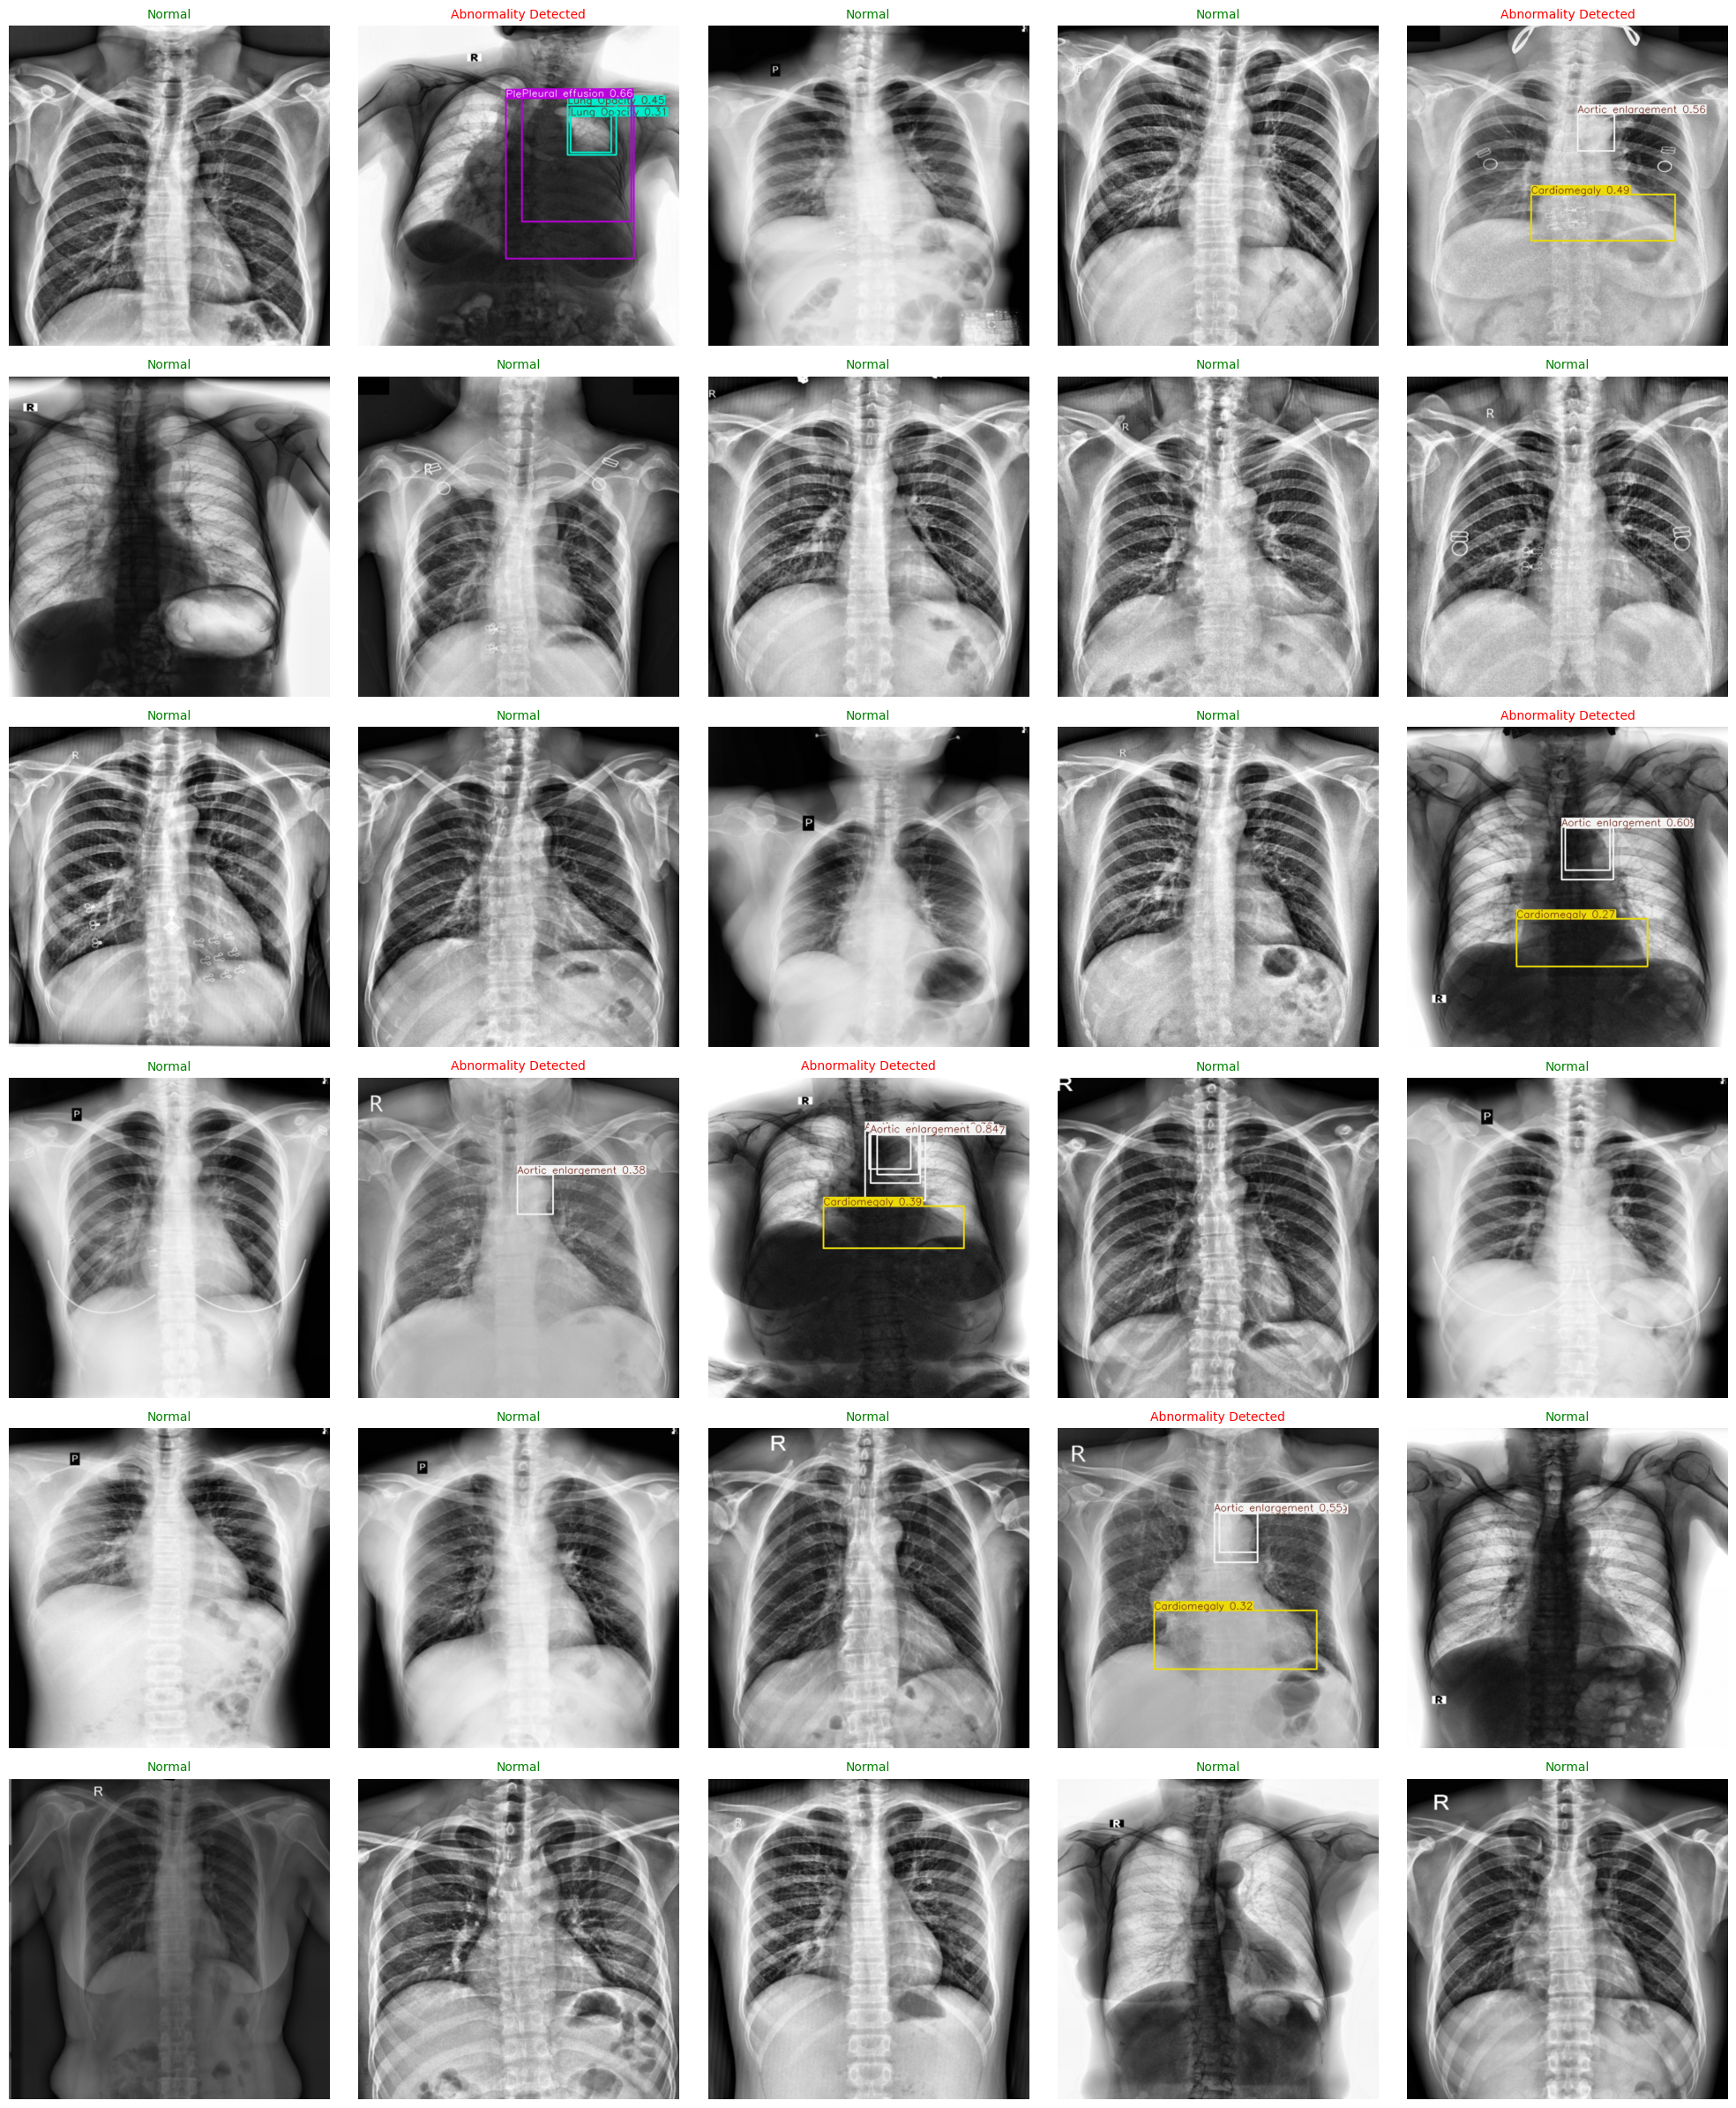

In [44]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
from PIL import Image

# Load trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Validation images folder
image_dir = "/kaggle/working/yolo_dataset/images/val"
image_files = os.listdir(image_dir)

num_images = 30
cols = 5
rows = 6

plt.figure(figsize=(20,24))

for i, img_name in enumerate(image_files[:num_images]):

    img_path = os.path.join(image_dir, img_name)

    # Run detection
    results = model.predict(img_path, conf=0.25, verbose=False)

    plt.subplot(rows, cols, i+1)

    if len(results[0].boxes) > 0:

        plotted_img = results[0].plot()
        plt.imshow(plotted_img)

        plt.title("Abnormality Detected", fontsize=10, color="red")

    else:

        img = Image.open(img_path)
        plt.imshow(img, cmap="gray")

        plt.title("Normal", fontsize=10, color="green")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
import shutil
from pathlib import Path

# Define the folder path
folder_path = Path("/kaggle/working/runs")

# Define the output zip file path in output directory
zip_path = "/kaggle/working/runs.zip"

# Compress the folder into output directory
shutil.make_archive(base_name=zip_path.replace(".zip", ""), format='zip', root_dir=folder_path)

print(f"Zip file created at: {zip_path}")

Zip file created at: /kaggle/working/runs.zip
